In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from dataloader import WVSDataLoader

In [2]:
time_series_data_file = '/home/tchakrab/gb-scratch/wvs/data/WVS_Time_Series_1981-2022_csv_v5_0.csv'
time_series_data = WVSDataLoader(time_series_data_file)

In [18]:
demographic_data = {
    "X001": "Sex",
    "X002": "Year of birth",
    "X003": "Age (years)",
    "X007": "Marital status",
    "X011": "Number of children",
    "X025": "Highest education level achieved",
    "X025R": "Education level (recoded)",
    "X026": "Lives with parents",
    "X028": "Employment status",
    "X036": "Type of main profession (ISCO)",
    "X040": "Chief wage earner in household",
    "X044": "Family savings",
    "X045": "Self-reported social class",
    "X047R_WVS": "Income level (recoded)",
    "X049": "Size of town OR settlement size",
    "X051": "Ethnic group",
}


In [59]:
wave_number = 3
wave_data = time_series_data.df[(time_series_data.df['S002VS'] == wave_number) & (time_series_data.df['COUNTRY_ALPHA'] == 'IND')]
wave_data.head()
print(len(wave_data))  # Number of respondents in wave 3 from India

2040


In [56]:
X001_map = {
    1: "male",
    2: "female",
}
X007_map = {
    1: "married",
    2: "living together as married",
    3: "divorced",
    4: "separated",
    5: "widowed",
    6: "either single or never married",
}
X026_map = {
    0: "do not live",
    1: "live",
}
X028_map = {
    1: "employed full-time",
    2: "employed part-time",
    3: "self-employed",
    4: "retired",
    5: "housewife",
    6: "student",
    7: "unemployed",
    8: "other",
}

X036_map = {
    # Employers / managers
    11: "employer or manager of an establishment with 500 or more employees",
    12: "employer or manager of an establishment with 100 or more employees",
    13: "employer or manager of an establishment with 10 or more employees",
    14: "employer or manager of an establishment with fewer than 500 employees",
    15: "employer or manager of an establishment with fewer than 100 employees",
    16: "employer or manager of an establishment with fewer than 10 employees",

    # Non-manual
    21: "professional worker",
    22: "middle-level non-manual office worker",
    23: "supervisory non-manual office worker",
    24: "junior-level non-manual worker",
    25: "non-manual office worker",

    # Manual
    31: "foreman or supervisor",
    32: "skilled manual worker",
    33: "semi-skilled manual worker",
    34: "unskilled manual worker",

    # Agriculture
    41: "farmer with own farm",
    42: "agricultural worker",

    # Other
    51: "member of the armed forces",
    61: "never had a job",
    81: "other",
}

X040_map = {
    1: "are",
    2: "are not",
}

X044_map = {
    1: "was able to save money",
    2: "just got by",
    3: "spent some savings",
    4: "spent savings and borrowed money",
}

X045_map = {
    1: "upper class",
    2: "upper middle class",
    3: "lower middle class",
    4: "working class",
    5: "lower class",
}

X047R_WVS_map = {
    1: "low income",
    2: "medium income",
    3: "high income",
}

X049_map = {
    1: "a town with under 2,000 people",
    2: "a town with 2,000–5,000 people",
    3: "a town with 5,000–10,000 people",
    4: "a town with 10,000–20,000 people",
    5: "a town with 20,000–50,000 people",
    6: "a town with 50,000–100,000 people",
    7: "a city with 100,000–500,000 people",
    8: "a city with over 500,000 people",
}

X025R_map = {
    1: "lower level",
    2: "middle level",
    3: "upper level",
}


In [74]:
import json
prompts = []
prompt_to_code = {}
# Load the survey questions
with open("/home/tchakrab/gb-scratch/wvs/data/parsed_survey_data.json", "r") as f:
    survey_questions = json.load(f)

# Load prompt templates
with open("/home/tchakrab/gb-scratch/wvs/code/prompts/system/llm_baseline_predict_value_changes.txt", "r") as f:
    system_prompt = eval(f.read())
with open("/home/tchakrab/gb-scratch/wvs/code/prompts/user/llm_baseline_predict_value_changes.txt", "r") as f:
    user_prompt = f.read()

# Process each person from wave_data
for row in wave_data.itertuples():  # or use wave_data.itertuples() for all rows
    
    # For each question in the survey
    for question_code, question_data in survey_questions.items():

        actual_answer = row[question_code].iloc[0] if question_code in row.columns else None
        if actual_answer < 0: continue
        
        filled_prompt = eval(user_prompt.format(
            X003=row.X003,
            X001=X001_map.get(row.X001, "?"),
            country=row.COUNTRY_ALPHA,
            X002=row.X002,
            X049=X049_map.get(row.X049, "?"),
            X026=X026_map.get(row.X026, "?"),
            X007=X007_map.get(row.X007, "?"),
            X011=row.X011,
            X025R=X025R_map.get(row.X025R, "?"),
            X028=X028_map.get(row.X028, "?"),
            X036=X036_map.get(row.X036, "?"),
            X040=X040_map.get(row.X040, "?"),
            X044=X044_map.get(row.X044, "?"),
            X045=X045_map.get(row.X045, "?"),
            X047R_WVS=X047R_WVS_map.get(row.X047R_WVS, "?"),
            label=question_data.get('label', '?'),
            question=question_data.get('parsed_question', '?'),
            options=', '.join(question_data.get('choices', [])),
        ))
        prompts.append(filled_prompt)

        prompt_to_code[filled_prompt] = str(row.Index) + " " + question_code

AttributeError: 'Pandas' object has no attribute 'columns'

In [73]:
def count_questions_by_prefix(data_dictionary):
    """
    Counts the number of questions for each unique prefix in the dictionary keys.

    Args:
        data_dictionary (dict): The dictionary with question IDs as keys.

    Returns:
        dict: A dictionary where keys are prefixes (e.g., 'A', 'B') and values 
              are the counts of questions starting with that prefix.
    """
    prefix_counts = {}
    
    # Iterate over all keys in the dictionary
    for key in data_dictionary.keys():
        # Assuming the prefix is the first non-numeric part (e.g., 'A' in 'A001')
        prefix = key[0]
        
        # If the key has a non-empty prefix, update the count
        if prefix:
            if prefix in prefix_counts:
                prefix_counts[prefix] += 1
            else:
                prefix_counts[prefix] = 1
                
    return prefix_counts

count = count_questions_by_prefix(survey_questions)
print(count)  # Example output: {'A': 10, 'B': 15, ...}
print(len(survey_questions))  # Total number of generated prompts

{'A': 148, 'B': 25, 'C': 38, 'D': 62, 'E': 219, 'F': 124, 'G': 54, 'H': 7, 'I': 2}
679


In [58]:
import os
from thread_gpt_suite.thread_gpt_mp_handler import ThreadGPTMPHandler
handler = ThreadGPTMPHandler(api_key=os.environ.get("OPENAI_API_KEY"), num_worker=350)
batch = [
    {
        "questions": [prompt],          # single-turn
        "model_name": "gpt-4.1-mini",    # change if needed
        "task_desc": system_prompt      # system prompt
    }
    for prompt in prompts
]

# Add and process (same API)
handler.add_batch(batch)
results = handler.process(rerun_on_error=True)

Processing Batch: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 3395/3395 [00:43<00:00, 78.09conv/s]


In [62]:
results_json = {}
for result in results:
    for prompt, response in result.items():
        code = prompt_to_code[prompt]
        results_json[code] = {"prompt": prompt, "response": response}

In [63]:
with open("/home/tchakrab/gb-scratch/wvs/results/llm_baseline_predict_value_changes_results_ind.json", "w") as f:
    json.dump(results_json, f, indent=4)

In [64]:
import json
import re

# Load the LLM results
with open("/home/tchakrab/gb-scratch/wvs/results/llm_baseline_predict_value_changes_results_ind.json", "r") as f:
    llm_baseline_predict_value_changes_results = json.load(f)

# Function to extract predicted answer from LLM response
def extract_predicted_answer(response_text):
    """Extract the numerical answer from LLM response"""
    # Look for patterns like "Final Answer: 1" or just "1 Very important"
    patterns = [
        r"Final Answer:\s*(\d+)",
        r"Answer:\s*(\d+)",
        r"^(\d+)\s+",  # Number at start of line
        r"\b(\d+)\b"   # Any standalone number
    ]
    
    for pattern in patterns:
        match = re.search(pattern, response_text, re.MULTILINE)
        if match:
            return int(match.group(1))
    
    return None

# Create comparison dataframe
comparison_results = []

for entry_key, entry_data in llm_baseline_predict_value_changes_results.items():
    # Parse the entry key (e.g., "402537 A001")
    parts = entry_key.split()
    person_index = int(parts[0])
    question_code = parts[1]
    
    # Get the actual answer from wave_data
    person_row = wave_data[wave_data.index == person_index]
    if len(person_row) == 0:
        continue
        
    actual_answer = person_row[question_code].iloc[0] if question_code in person_row.columns else None
    if actual_answer < 0:
        actual_answer = None  # Treat -1 as missing
        continue
    
    # Extract predicted answer from LLM response
    predicted_answer = extract_predicted_answer(entry_data["response"])
    
    comparison_results.append({
        "person_index": person_index,
        "question_code": question_code,
        "actual_answer": actual_answer,
        "predicted_answer": predicted_answer,
        "llm_response": entry_data["response"]
    })

# Convert to DataFrame for easier analysis
comparison_df = pd.DataFrame(comparison_results)

# Display first few results
print("First 10 comparisons:")
print(comparison_df[["person_index", "question_code", "actual_answer", "predicted_answer"]].head(10))

# Calculate accuracy (where both answers are valid)
valid_comparisons = comparison_df.dropna(subset=["actual_answer", "predicted_answer"])
accuracy = (valid_comparisons["actual_answer"] == valid_comparisons["predicted_answer"]).mean()
print(f"\nAccuracy: {accuracy:.3f} ({len(valid_comparisons)} valid comparisons)")

First 10 comparisons:
   person_index question_code  actual_answer  predicted_answer
0        172524          A001              1               1.0
1        172524          A002              2               2.0
2        172524          A003              2               2.0
3        172524          A004              3               2.0
4        172524          A005              1               3.0
5        172524          A006              3               1.0
6        172524          A008              2               3.0
7        172524          A009              2               3.0
8        172524          A025              1               1.0
9        172524          A026              2               1.0

Accuracy: 0.465 (796 valid comparisons)


In [36]:
# waves_end = [2, 3, 4, 5, 6, 7]

# prefixes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']

# for i in waves_end:
#     for j in range(1, i):
#         start_wave = j
#         end_wave = i
#         print(f'Processing significant changes from wave {start_wave} to wave {end_wave}')
#         all_changes_list = []
#         for p in prefixes:
#             changes = time_series_data.get_significant_changes(
#                 wave1=start_wave, 
#                 wave2=end_wave, 
#                 alpha=0.05, 
#                 question_prefix=p
#             )
#             all_changes_list.append(changes)
    
#         final_results_df = pd.concat(all_changes_list, ignore_index=True)
#         final_results_df.to_csv(f'/home/tchakrab/gb-scratch/wvs/data/significant_changes/wave{start_wave}_to_wave{end_wave}.csv', index=False)


In [4]:
# save the results
# final_results_df.to_csv('/home/tchakrab/gb-scratch/wvs/data/wvs_significant_changes_wave6_wave7.csv', index=False)
start_wave = 6
end_wave = 7
final_results_df = pd.read_csv(f'/home/tchakrab/gb-scratch/wvs/data/significant_changes/wave{start_wave}_to_wave{end_wave}.csv')

In [5]:
variable_lookup_df = pd.read_csv('/home/tchakrab/gb-scratch/wvs/data/WVS_Time_Series_Vars.csv')
var_to_title = variable_lookup_df.set_index('Variable')['Title'].to_dict()


In [17]:
start_wave = 6
end_wave = 7
final_results_df = pd.read_csv(f'/home/tchakrab/gb-scratch/wvs/data/significant_changes/wave{start_wave}_to_wave{end_wave}.csv')
for row in final_results_df.itertuples():
    country = row.country
    question = var_to_title[row.question]
    x = getattr(row, f"mean_wave_{start_wave}")
    y = getattr(row, f"mean_wave_{end_wave}")
    if abs(x - y) < 1: continue
    print(f"Change from Wave {start_wave} to wave {end_wave} for {country}:")
    print(f"Question: {question}")
    print(f"Wave {start_wave}: {x}, Wave {end_wave}: {y}")
    print()
    


Change from Wave 6 to wave 7 for JOR:
Question: Active/Inactive membership of any other organization
Wave 6: 0.0083333333333333, Wave 7: 1.9866999168744808

Change from Wave 6 to wave 7 for ZWE:
Question: State of health (subjective)
Wave 6: 1.6906666666666668, Wave 7: 2.7775947281713345

Change from Wave 6 to wave 7 for IRQ:
Question: Satisfaction with your life
Wave 6: 5.914357682619648, Wave 7: 4.465

Change from Wave 6 to wave 7 for THA:
Question: How much freedom of choice and control
Wave 6: 7.527196652719665, Wave 7: 6.129443326626426

Change from Wave 6 to wave 7 for KGZ:
Question: Satisfaction with your life
Wave 6: 6.963087248322148, Wave 7: 8.38313856427379

Change from Wave 6 to wave 7 for ARM:
Question: How much freedom of choice and control
Wave 6: 6.360113421550095, Wave 7: 7.768595041322314

Change from Wave 6 to wave 7 for LBN:
Question: How much freedom of choice and control
Wave 6: 6.968227424749164, Wave 7: 5.880833333333333

Change from Wave 6 to wave 7 for ARM:
Qu

In [7]:
start_wave = 6
end_wave = 7
final_results_df = pd.read_csv(f'/home/tchakrab/gb-scratch/wvs/data/significant_changes/wave{start_wave}_to_wave{end_wave}.csv')
results_by_country = {}

for row in final_results_df.itertuples():
    country = row.country
    question = row.question
    
    x = getattr(row, f"mean_wave_{start_wave}")
    y = getattr(row, f"mean_wave_{end_wave}")
    
    if abs(x - y) < 1:
        continue
    
    if question in ['E179WVS', 'E179_WVS7LOC', 'F025_WVS', 'G016']: continue
    
    # Initialize the list for this country if needed
    if country not in results_by_country:
        results_by_country[country] = []
    
    results_by_country[country].append(
        (question, x, y)
    )

# Print grouped results
for country, entries in results_by_country.items():
    print(f"=== {country} ===")
    for question, x, y in entries:
        print(f"    Question: {question} {var_to_title[question]}")
        print(f"    Wave {start_wave}: {x}, Wave {end_wave}: {y}")
        print()


=== JOR ===
    Question: A106 Active/Inactive membership of any other organization
    Wave 6: 0.0083333333333333, Wave 7: 1.9866999168744808

    Question: E036 Private vs state ownership of business
    Wave 6: 6.717796610169492, Wave 7: 5.532133676092545

=== ZWE ===
    Question: A009 State of health (subjective)
    Wave 6: 1.6906666666666668, Wave 7: 2.7775947281713345

    Question: A170 Satisfaction with your life
    Wave 6: 6.041333333333333, Wave 7: 4.950576606260297

    Question: C006 Satisfaction with financial situation of household
    Wave 6: 4.817333333333333, Wave 7: 3.6446826051112944

    Question: E248B Information source: Daily newspaper (B)
    Wave 6: 2.678, Wave 7: 3.952814569536424

    Question: E258B Information source: TV news (B)
    Wave 6: 2.034, Wave 7: 3.2866611433305715

    Question: E233A Democracy: The state makes people's incomes equal
    Wave 6: 4.124666666666666, Wave 7: 6.352206494587843

    Question: E236 Democraticness in own country
    

In [20]:
from gdelt_wrapper import GDELTNewsFetcher

fetcher = GDELTNewsFetcher(
    project_id="gdelt-project-472319",
    service_account_json="/home/tchakrab/gb-scratch/wvs/code/gdelt-project-472319-7dc52e752c93.json"
)

df = fetcher.get_articles(
    start_datetime=20240101000000,
    end_datetime=20240131235959,
    country_code="US",
    keywords=["election", "economy", "trump"],
    sources=["nytimes.com", "foxnews.com"],
    limit=100
)

/scratch/gilbreth/tchakrab/conda/wvs/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


KeyboardInterrupt: 

In [16]:
print(df.iloc[1]['text'])


        This material may not be published, broadcast, rewritten, or redistributed. ©2025 FOX News Network, LLC. All rights reserved. Quotes displayed in real-time or delayed by at least 15 minutes. Market data provided by Factset. Powered and implemented by FactSet Digital Solutions. Legal Statement. Mutual Fund and ETF data provided by Refinitiv Lipper.
       Nicole Smith is a Charlotte, North Carolina, resident who recently became frustrated when the Chick-fil-A across from her apartment was playing loud music in the middle of the night.  An ex-felon can run for a North Carolina legislative seat this year, the State Board of Elections ruled on Tuesday, upholding a county election board's determination that he's been discharged for the crimes from another state. State board members participating in the meeting voted unanimously to confirm last week's divided decision by the Rockingham County Board of Elections to deny a candidate challenge against Joseph Gibson III and to declare h

In [8]:
import os
sig_changes_files = '/home/tchakrab/gb-scratch/wvs/data/significant_changes'
change_count = {}
for file in os.listdir(sig_changes_files):
    if file.endswith('.csv'):
        wave_combo = file.split('.')[0]
        df = pd.read_csv(os.path.join(sig_changes_files, file))
        country_counts = df['country'].value_counts()
        total_change = country_counts.sum()
        country_counts_dict = country_counts.to_dict()
        country_counts_dict['total'] = int(total_change)
        change_count[wave_combo] = country_counts_dict

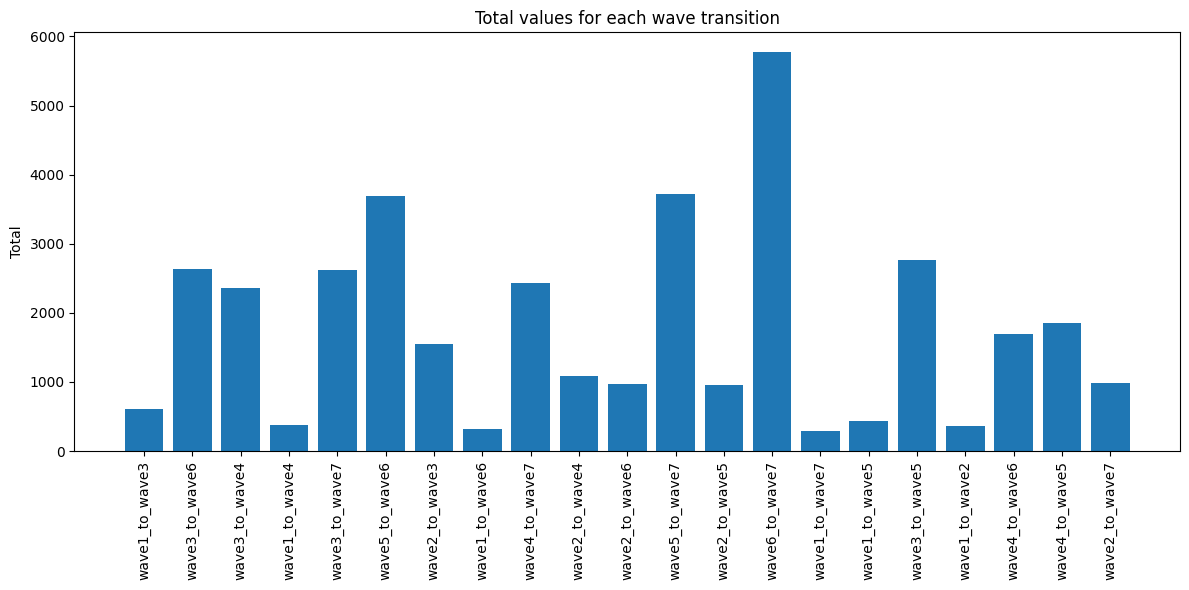

In [ ]:
import matplotlib.pyplot as plt

wave_labels = []
totals = []
sum = 0

for wave, values in change_count.items():
    if "total" in values:
        wave_labels.append(wave)
        totals.append(values["total"])
        sum += values["total"]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(wave_labels, totals)
plt.xticks(rotation=90)
plt.ylabel("Total")
plt.title("Total significant changes for each wave combination")
plt.tight_layout()
plt.show()

In [9]:
change_count['wave5_to_wave6']


{'ZAF': 137,
 'IND': 128,
 'ROU': 125,
 'THA': 122,
 'JOR': 121,
 'RWA': 117,
 'GHA': 116,
 'CHN': 114,
 'MAR': 110,
 'BRA': 108,
 'MYS': 107,
 'DEU': 106,
 'TWN': 105,
 'GEO': 104,
 'EGY': 102,
 'MEX': 102,
 'RUS': 101,
 'UKR': 100,
 'CHL': 100,
 'TUR': 98,
 'NLD': 98,
 'ESP': 97,
 'ARG': 94,
 'SWE': 93,
 'SVN': 93,
 'PER': 91,
 'URY': 88,
 'COL': 87,
 'POL': 83,
 'CYP': 83,
 'USA': 78,
 'AUS': 77,
 'TTO': 77,
 'KOR': 76,
 'JPN': 75,
 'HKG': 69,
 'IRQ': 66,
 'NZL': 36,
 'total': 3684}